<a href="https://colab.research.google.com/github/Marconi-Lab/Solar_irradiation/blob/rm%2Fdata_cleaning/jupyter_notebooks/bias_extraction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Accessing Github data files from colab
from google.colab import userdata
token = userdata.get('github')
!git clone -b rm/data_cleaning https://{token}@github.com/Marconi-Lab/Solar_irradiation.git

Cloning into 'Solar_irradiation'...
remote: Enumerating objects: 19319, done.
remote: Counting objects: 100% (43/43), done.
remote: Compressing objects: 100% (36/36), done.
remote: Total 19319 (delta 11), reused 7 (delta 7), pack-reused 19276 (from 3)
Receiving objects: 100% (19319/19319), 199.16 MiB | 10.63 MiB/s, done.
Resolving deltas: 100% (2890/2890), done.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
# # For colab
# measurement_folder = Path("/content/Solar_irradiation/jupyter_notebooks/Data/irradiation_measurements")
# estimates_folder = Path("/content/Solar_irradiation/jupyter_notebooks/Data/irradiation_estimates")

# For local
measurement_folder = Path("Data/irradiation_measurements")
estimates_folder = Path("Data/irradiation_estimates")


In [3]:
cbe_estimates = estimates_folder / 'CBE_Data'
cbe_measurements = measurement_folder / 'CBE_Data'
ministy_estimates = estimates_folder / 'ministry_energy_ug'
ministy_measurements = measurement_folder / 'ministry_energy_ug'

cbe_estimates_files = list(cbe_estimates.glob('*.csv'))
cbe_measurements_files = list(cbe_measurements.glob('*.csv'))
ministy_estimates_files = list(ministy_estimates.glob('*.csv'))
ministy_measurements_files = list(ministy_measurements.glob('*.csv'))

all_files = cbe_estimates_files + cbe_measurements_files + ministy_estimates_files + ministy_measurements_files
all_files.sort()
all_files

[PosixPath('Data/irradiation_estimates/CBE_Data/egypt_cams.csv'),
 PosixPath('Data/irradiation_estimates/CBE_Data/egypt_nasa.csv'),
 PosixPath('Data/irradiation_estimates/CBE_Data/egypt_solcast.csv'),
 PosixPath('Data/irradiation_estimates/CBE_Data/ghana_cams.csv'),
 PosixPath('Data/irradiation_estimates/CBE_Data/ghana_nasa.csv'),
 PosixPath('Data/irradiation_estimates/CBE_Data/ghana_solcast.csv'),
 PosixPath('Data/irradiation_estimates/CBE_Data/kenya_nasa.csv'),
 PosixPath('Data/irradiation_estimates/CBE_Data/madagascar_cams.csv'),
 PosixPath('Data/irradiation_estimates/CBE_Data/madagascar_nasa.csv'),
 PosixPath('Data/irradiation_estimates/CBE_Data/madagascar_solcast.csv'),
 PosixPath('Data/irradiation_estimates/CBE_Data/nigeria_cams.csv'),
 PosixPath('Data/irradiation_estimates/CBE_Data/nigeria_nasa.csv'),
 PosixPath('Data/irradiation_estimates/CBE_Data/somalia_cams.csv'),
 PosixPath('Data/irradiation_estimates/CBE_Data/somalia_nasa.csv'),
 PosixPath('Data/irradiation_estimates/CBE_D

In [4]:

egypt_cams = pd.read_csv(all_files[0])
egypt_nasa = pd.read_csv(all_files[1])
egypt_solcast = pd.read_csv(all_files[2])
ghana_cams = pd.read_csv(all_files[3])
ghana_nasa = pd.read_csv(all_files[4])
ghana_solcast = pd.read_csv(all_files[5])
kenya_nasa = pd.read_csv(all_files[6])
madagascar_cams = pd.read_csv(all_files[7])
madagascar_nasa = pd.read_csv(all_files[8])
madagascar_solcast = pd.read_csv(all_files[9])
nigeria_cams = pd.read_csv(all_files[10])
nigeria_nasa = pd.read_csv(all_files[11])
somalia_cams = pd.read_csv(all_files[12])
somalia_nasa = pd.read_csv(all_files[13])
somalia_solcast = pd.read_csv(all_files[14])
soroti_cams = pd.read_csv(all_files[15])
soroti_nasa = pd.read_csv(all_files[16])
soroti_nrel = pd.read_csv(all_files[17])
soroti_solcast = pd.read_csv(all_files[18])
wadelai_cams = pd.read_csv(all_files[19])
wadelai_nasa = pd.read_csv(all_files[20])
wadelai_nrel = pd.read_csv(all_files[21])
wadelai_solcast = pd.read_csv(all_files[22])

egypt_ground = pd.read_csv(all_files[23])
ghana_ground = pd.read_csv(all_files[24])
kenya_ground = pd.read_csv(all_files[25])
madagascar_ground = pd.read_csv(all_files[26])
nigeria_ground = pd.read_csv(all_files[27])
somalia_ground = pd.read_csv(all_files[28])
soroti_ground = pd.read_csv(all_files[29])
wadelai_ground = pd.read_csv(all_files[30])

egypt_cams.index = pd.to_datetime(egypt_cams['datetime'])
egypt_nasa.index = pd.to_datetime(egypt_nasa['datetime'])
egypt_solcast.index = pd.to_datetime(egypt_solcast['datetime'])
egypt_ground.index = pd.to_datetime(egypt_ground['datetime'])
ghana_cams.index = pd.to_datetime(ghana_cams['datetime'])
ghana_nasa.index = pd.to_datetime(ghana_nasa['datetime'])
ghana_solcast.index = pd.to_datetime(ghana_solcast['datetime'])
ghana_ground.index = pd.to_datetime(ghana_ground['datetime'])
kenya_nasa.index = pd.to_datetime(kenya_nasa['datetime'])
kenya_ground.index = pd.to_datetime(kenya_ground['datetime'])
madagascar_cams.index = pd.to_datetime(madagascar_cams['datetime'])
madagascar_nasa.index = pd.to_datetime(madagascar_nasa['datetime'])
madagascar_solcast.index = pd.to_datetime(madagascar_solcast['datetime'])
madagascar_ground.index = pd.to_datetime(madagascar_ground['datetime'])
nigeria_cams.index = pd.to_datetime(nigeria_cams['datetime'])
nigeria_nasa.index = pd.to_datetime(nigeria_nasa['datetime'])
nigeria_ground.index = pd.to_datetime(nigeria_ground['datetime'])
somalia_cams.index = pd.to_datetime(somalia_cams['datetime'])
somalia_nasa.index = pd.to_datetime(somalia_nasa['datetime'])
somalia_solcast.index = pd.to_datetime(somalia_solcast['datetime'])
somalia_ground.index = pd.to_datetime(somalia_ground['datetime'])
soroti_cams.index = pd.to_datetime(soroti_cams['datetime'])
soroti_nasa.index = pd.to_datetime(soroti_nasa['datetime'])
soroti_nrel.index = pd.to_datetime(soroti_nrel['datetime'])
soroti_solcast.index = pd.to_datetime(soroti_solcast['datetime'])
soroti_ground.index = pd.to_datetime(soroti_ground['datetime'])
wadelai_cams.index = pd.to_datetime(wadelai_cams['datetime'])
wadelai_nasa.index = pd.to_datetime(wadelai_nasa['datetime'])
wadelai_nrel.index = pd.to_datetime(wadelai_nrel['datetime'])
wadelai_solcast.index = pd.to_datetime(wadelai_solcast['datetime'])
wadelai_ground.index = pd.to_datetime(wadelai_ground['datetime'])



In [5]:
egypt = [egypt_cams, egypt_nasa, egypt_solcast, egypt_ground]
ghana = [ghana_cams, ghana_nasa, ghana_solcast, ghana_ground]
kenya = [kenya_nasa, kenya_ground]
madagascar = [madagascar_cams, madagascar_nasa, madagascar_solcast, madagascar_ground]
nigeria = [nigeria_cams, nigeria_nasa, nigeria_ground]
somalia = [somalia_cams, somalia_nasa, somalia_solcast, somalia_ground]
soroti = [soroti_cams, soroti_nasa, soroti_nrel, soroti_solcast, soroti_ground]
wadelai = [wadelai_cams, wadelai_nasa, wadelai_nrel, wadelai_solcast, wadelai_ground]   

In [6]:
def compute_daily_errors(site_dataframes, site_name):
    """
    Compute daily percentage errors between ground data and estimators for a site.

    Parameters:
    -----------
    site_dataframes : list
        List of pandas DataFrames for a site where the last DataFrame is ground truth
    site_name : str
        Name of the site

    Returns:
    --------
    pandas.DataFrame
        DataFrame with daily percentage errors for each estimator and location
    """
    # Get ground truth data (last DataFrame in the list)
    ground_df = site_dataframes[-1]

    # Initialize empty list to store daily errors
    daily_errors = []

    # Iterate through estimator dataframes (all except the last one)
    for estimator_df in site_dataframes[:-1]:
        # Get estimator name from the 'estimator' column
        estimator_name = estimator_df['estimator'].iloc[0] if 'estimator' in estimator_df.columns else 'unknown'

        # Group by location
        locations = estimator_df['location'].unique() if 'location' in estimator_df.columns else ['unknown']

        for location in locations:
            # Filter data for current location
            if 'location' in estimator_df.columns:
                est_loc_data = estimator_df[estimator_df['location'] == location]
            else:
                est_loc_data = estimator_df

            # Merge dataframes on datetime index
            merged_data = est_loc_data.join(ground_df['ghi'], how='inner', lsuffix='_est', rsuffix='_ground')

            if not merged_data.empty:
                # Calculate daily percentage error for each data point
                merged_data['percentage_error'] = ((merged_data['ghi_est'] - merged_data['ghi_ground']) /
                                               merged_data['ghi_ground']) * 100
                merged_data['absolute_percentage_error'] = abs(merged_data['percentage_error'])
                merged_data['squared_error'] = (merged_data['ghi_est'] - merged_data['ghi_ground']) ** 2
                
                # drop rows with absolute percentage error > 1000
                merged_data = merged_data[merged_data['absolute_percentage_error'] < 1000]
                
                # Add metadata columns
                merged_data['site'] = site_name
                merged_data['location'] = location
                merged_data['estimator'] = estimator_name
                # merged_data['datetime'] = merged_data.index

                # Select relevant columns for the error dataframe
                error_data = merged_data[['datetime', 'site', 'location', 'estimator',
                                          'ghi_est', 'ghi_ground',
                                          'percentage_error', 'absolute_percentage_error',
                                          'squared_error']].copy()

                daily_errors.append(error_data)

    # Combine all daily errors into a single DataFrame
    if daily_errors:
        return pd.concat(daily_errors)
    else:
        return pd.DataFrame()

def compute_all_sites_daily_errors(sites_list, site_names):
    """
    Compute daily errors for all sites and combine into a single DataFrame

    Parameters:
    -----------
    sites_list : list of lists
        List containing lists of DataFrames for each site
    site_names : list
        List of site names

    Returns:
    --------
    pandas.DataFrame
        Combined DataFrame with daily error metrics for all sites
    """
    all_daily_errors = []

    for site_dfs, site_name in zip(sites_list, site_names):
        site_daily_errors = compute_daily_errors(site_dfs, site_name)
        all_daily_errors.append(site_daily_errors)

    # Combine all daily errors
    combined_daily_errors = pd.concat(all_daily_errors, ignore_index=True)
    return combined_daily_errors

In [12]:
sites_list = [egypt, ghana, madagascar, nigeria, somalia, soroti, wadelai]
site_names = ['egypt', 'ghana', 'madagascar', 'nigeria', 'somalia', 'soroti', 'wadelai']

# Compute daily errors for all sites
daily_errors = compute_all_sites_daily_errors(sites_list, site_names)

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt

def plot_error_monthly_distribution(daily_errors_df, error_type='percentage_error', output_dir='error_plots'):
    """
    Create figures showing monthly error distribution by year for each location.

    Parameters:
    -----------
    daily_errors_df : pandas.DataFrame
        DataFrame containing error data with datetime index
    error_type : str
        Type of error to plot ('percentage_error' or 'absolute_percentage_error')
    output_dir : str
        Directory to save plots (default: 'error_plots')

    Returns:
    --------
    None
    """
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)

    data = daily_errors_df.copy().reset_index()

    if 'datetime' not in data.columns:
        data['datetime'] = data['index']

    # Prepare date-related columns
    data['Date'] = pd.to_datetime(data['datetime'])
    data['Year'] = data['Date'].dt.year
    data['Month'] = data['Date'].dt.month  # Monthly resolution

    # Determine error label based on type
    error_label = 'Percentage Error (%)' if error_type == 'percentage_error' else 'Absolute Percentage Error (%)'

    # Get unique combinations of site, location, and estimator
    for site in data['site'].unique():
        site_data = data[data['site'] == site]

        for location in site_data['location'].unique():
            location_data = site_data[site_data['location'] == location]

            for estimator in location_data['estimator'].unique():
                est_data = location_data[location_data['estimator'] == estimator]

                # Skip if insufficient data
                if len(est_data) < 10:
                    continue

                # Create the figure
                plt.figure(figsize=(10, 5))

                # Errors for all years overlaid (Monthly)
                years = sorted(est_data['Year'].unique())
                color_list = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd',
                              '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']
                colors = [color_list[i % len(color_list)] for i in range(len(years))]

                for i, year in enumerate(years):
                    year_data = est_data[est_data['Year'] == year]
                    monthly_avg = year_data.groupby('Month')[error_type].mean()

                    if len(monthly_avg) > 0:
                        mean_error = monthly_avg.mean()
                        plt.plot(monthly_avg.index, monthly_avg,
                                 color=colors[i], alpha=0.7,
                                 label=f'{year} (Mean: {mean_error:.2f})')

                if error_type == 'percentage_error':
                    plt.axhline(y=0, color='black', linestyle='--', alpha=0.5)

                plt.xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                                          'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
                plt.xlabel('Month')
                plt.ylabel(error_label)
                plt.title(f'Monthly {error_label} in {location}\n{estimator} ({site})')
                if len(years) <= 10:
                    plt.legend(loc='best')
                plt.grid(True, alpha=0.1)

                plt.tight_layout()
                plt.show()


# Example usage (assuming daily_errors is already computed)
plot_error_monthly_distribution(daily_errors, error_type='percentage_error')
# plot_error_monthly_distribution(daily_errors, error_type='absolute_percentage_error')


In [ ]:
def plot_error_yearly_distribution(daily_errors_df, error_type='percentage_error', output_dir='error_plots'):
    """
    Create separate figures showing error distribution by year and daily statistics for each location.

    Parameters:
    -----------
    daily_errors_df : pandas.DataFrame
        DataFrame containing error data with datetime index
    error_type : str
        Type of error to plot ('percentage_error' or 'absolute_percentage_error')
    output_dir : str
        Directory to save plots (default: 'error_plots')

    Returns:
    --------
    None
    """
    import os
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)

    data = daily_errors_df.copy().reset_index()

    if 'datetime' not in data.columns:
        data['datetime'] = data['index']

    # Prepare date-related columns
    data['Date'] = pd.to_datetime(data['datetime'])
    data['Year'] = data['Date'].dt.year
    data['DayOfYear'] = data['Date'].dt.dayofyear

    # Determine error label based on type
    error_label = 'Percentage Error (%)' if error_type == 'percentage_error' else 'Absolute Percentage Error (%)'

    # Get unique combinations of site, location, and estimator
    for site in data['site'].unique():
        site_data = data[data['site'] == site]

        for location in site_data['location'].unique():
            location_data = site_data[site_data['location'] == location]

            for estimator in location_data['estimator'].unique():
                est_data = location_data[location_data['estimator'] == estimator]

                # Skip if insufficient data
                if len(est_data) < 10:
                    continue

                # Create the figure
                fig, axes = plt.subplots(1, 2, figsize=(15, 7))

                # Left plot: Errors for all years overlayed
                years = sorted(est_data['Year'].unique())
                color_list = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd',
                            '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']
                colors = [color_list[i % len(color_list)] for i in range(len(years))]
                
                # compute mean pearcebtage error for each year and add it to the legend
                
                for i, year in enumerate(years):
                    year_data = est_data[est_data['Year'] == year]
                    if len(year_data) > 0:
                        mean_error = year_data[error_type].mean()
                        axes[0].plot(year_data['DayOfYear'], year_data[error_type],
                                color=colors[i], alpha=0.7, label=f'{year} (Mean: {mean_error:.2f})')

                if error_type == 'percentage_error':
                    axes[0].axhline(y=0, color='black', linestyle='--', alpha=0.5)
                    
                axes[0].set_xlabel('Day of Year')
                axes[0].set_ylabel(error_label)
                axes[0].set_title(f'Daily {error_label} in {location}\n{estimator} ({site})')
                if len(years) <= 10:  # Only show legend if not too many years
                    axes[0].legend(loc='best')
                axes[0].grid(True, alpha=0.3)

                # Right plot: Daily mean and std across years
                daily_stats = est_data.groupby(['DayOfYear'])[error_type].agg(['mean', 'std']).reset_index()

                axes[1].plot(daily_stats['DayOfYear'], daily_stats['mean'],
                            color='blue', label=f'Mean {error_label}')

                # Only add std dev if we have enough data points
                if len(daily_stats) > 5:
                    axes[1].fill_between(
                        daily_stats['DayOfYear'],
                        daily_stats['mean'] - daily_stats['std'],
                        daily_stats['mean'] + daily_stats['std'],
                        color='blue', alpha=0.2, label='± 1 Std Dev'
                    )

                if error_type == 'percentage_error':
                    axes[1].axhline(y=0, color='black', linestyle='--', alpha=0.5)

                axes[1].set_xlabel('Day of Year')
                axes[1].set_ylabel(error_label)
                axes[1].set_title(f'Mean Daily {error_label} with Standard Deviation\n{estimator} ({site} - {location})')
                axes[1].legend(loc='best')
                axes[1].grid(True, alpha=0.3)

                plt.tight_layout()
                plt.show()

                # # Save the figure
                # filename = f"{site}_{location}_{estimator}_{error_type}_yearly.png".replace(" ", "_")
                # plt.savefig(f'{output_dir}/{filename}', dpi=300, bbox_inches='tight')
                # plt.close()

# Example usage (assuming daily_errors is already computed)
plot_error_yearly_distribution(daily_errors, error_type='percentage_error')
# plot_error_yearly_distribution(daily_errors, error_type='absolute_percentage_error')

In [122]:
daily_errors

,datetime,site,location,estimator,ghi_est,ghi_ground,percentage_error,absolute_percentage_error,squared_error
0,2023-09-01,egypt,egypt_location1,camsrad,7064.093,6428.052,9.894771,9.894771,404548.153681
1,2023-09-02,egypt,egypt_location1,camsrad,7397.833,6601.826,12.057376,12.057376,633627.144049
2,2023-09-03,egypt,egypt_location1,camsrad,7129.047,6600.638,8.005423,8.005423,279216.071281
3,2023-09-04,egypt,egypt_location1,camsrad,7328.903,6391.094,14.673685,14.673685,879485.720481
4,2023-09-05,egypt,egypt_location1,camsrad,7287.530,6373.021,14.349694,14.349694,836326.711081
...,...,...,...,...,...,...,...,...,...
126132,2021-12-27,wadelai,wadelai,solcast,5464.000,5540.000,-1.371841,1.371841,5776.000000
126133,2021-12-28,wadelai,wadelai,solcast,6391.000,6500.000,-1.676923,1.676923,11881.000000
126134,2021-12-29,wadelai,wadelai,solcast,6330.000,6240.000,1.442308,1.442308,8100.000000
126135,2021-12-30,wadelai,wadelai,solcast,6001.000,5950.000,0.857143,0.857143,2601.000000


In [16]:
mpe = daily_errors.groupby(['site', 'location', 'estimator'])['percentage_error'].mean()
mpe = mpe.reset_index()
mpe = mpe.rename(columns={'percentage_error': 'mean_percentage_error'})
mpe = mpe.sort_values(by='site')

In [17]:
rmse = np.sqrt(daily_errors.groupby(['site', 'location', 'estimator'])['squared_error'].mean())
rmse = rmse.reset_index()
rmse = rmse.rename(columns={'squared_error': 'rmse'})
rmse = rmse.sort_values(by='site')

In [18]:
mean_error = pd.merge(mpe, rmse, on=['site', 'location', 'estimator'])
mean_error

,site,location,estimator,mean_percentage_error,rmse
0,egypt,egypt_location1,camsrad,15.931019,1062.522226
1,egypt,egypt_location1,nasa_power,19.615557,1017.981307
2,egypt,egypt_location1,solcast,15.813004,894.352113
3,ghana,ghana_location1,camsrad,20.142729,1000.700293
4,ghana,ghana_location1,nasa_power,11.589844,807.233628
5,ghana,ghana_location1,solcast,18.125978,963.508685
6,ghana,ghana_location2,camsrad,19.895894,1028.242137
7,ghana,ghana_location2,nasa_power,14.537387,932.337749
8,ghana,ghana_location2,solcast,15.966920,907.977709
9,ghana,ghana_location3,camsrad,17.406643,931.942185


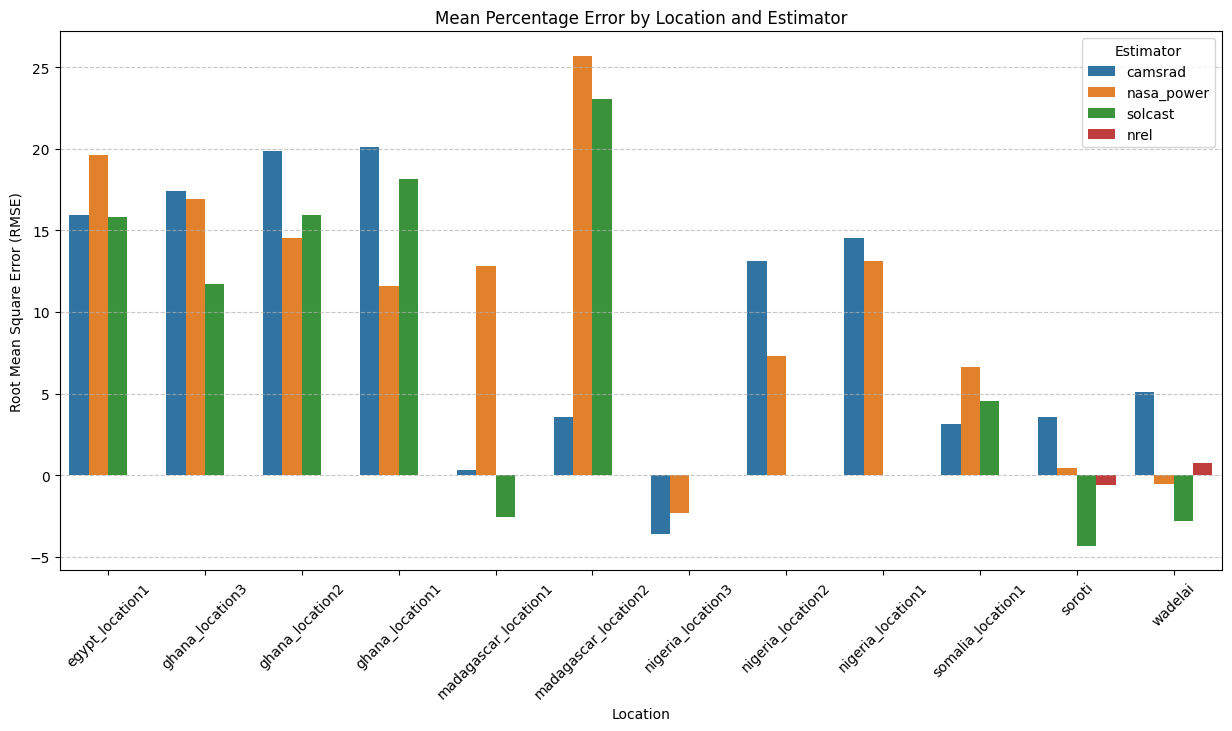

In [ ]:
# ignore kenya location 
mean_error = mean_error[~mean_error['site'].isin(['kenya'])]
plt.figure(figsize=(15, 7))
sns.barplot(data=mean_error, x="location", y="mean_percentage_error", hue="estimator")

# Formatting
plt.xticks(rotation=45)
plt.xlabel("Location")
plt.ylabel("Root Mean Square Error (RMSE)")
plt.title("Mean Percentage Error by Location and Estimator")
plt.legend(title="Estimator")
plt.grid(axis="y", linestyle="--", alpha=0.7)

# Show plot
plt.show()

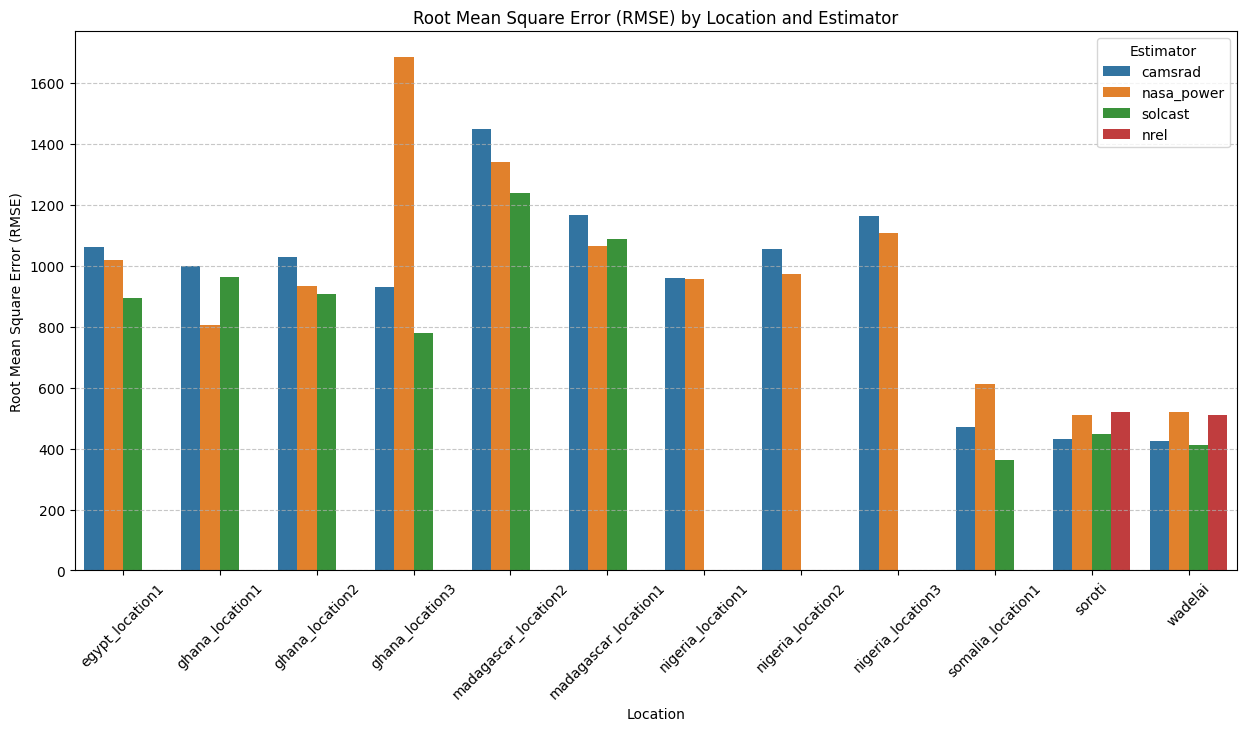

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# ignore kenya location 
mean_error = mean_error[~mean_error['site'].isin(['kenya'])]
plt.figure(figsize=(15, 7))
sns.barplot(data=mean_error, x="location", y="rmse", hue="estimator")

# Formatting
plt.xticks(rotation=45)
plt.xlabel("Location")
plt.ylabel("Root Mean Square Error (RMSE)")
plt.title("Root Mean Square Error (RMSE) by Location and Estimator")
plt.legend(title="Estimator")
plt.grid(axis="y", linestyle="--", alpha=0.7)

# Show plot
plt.show()